# GRU Traffic Volume Prediction

This notebook mirrors the current LSTM workflow, but uses a reusable `GRU_model.py` module so the prediction function can be imported later for route search integration.

In [1]:
import matplotlib.pyplot as plt

from GRU_model import get_locations, save_gru_plots, traffic_gru, train_gru_model

In [2]:
locations = get_locations()
print("Locations found:", locations)

Locations found: <StringArray>
['WARRIGAL_RD N of HIGH STREET_RD', 'HIGH STREET_RD E of WARRIGAL_RD',
 'WARRIGAL_RD S of HIGH STREET_RD', 'HIGH STREET_RD W of WARRIGAL_RD',
      'WARRIGAL_RD N of TOORAK_RD',    'BURWOOD_HWY E of WARRIGAL_RD',
    'WARRIGAL_RD S of BURWOOD_HWY',      'TOORAK_RD W of WARRIGAL_RD',
     'UNION_RD N of MAROONDAH_HWY',     'MAROONDAH_HWY E of UNION_RD',
 ...
    'GLENFERRIE_RD S OF COTHAM_RD',    'COTHAM_RD W OF GLENFERRIE_RD',
        'HIGH_ST NE of CHARLES_ST',         'SWAN_ST NE of MADDEN_GV',
          'MADDEN_GV S OF SWAN_ST',         'SWAN_ST SW of MADDEN_GV',
      'WALMER_ST N OF VICTORIA_ST',     'VICTORIA_ST E OF BURNLEY_ST',
     'BURNLEY_ST S OF VICTORIA_ST',     'VICTORIA_ST W OF BURNLEY_ST']
Length: 139, dtype: str


In [3]:
results = train_gru_model(loc_index=1, time_index=0)
print(f"Location: {results['location']}")
print(f"Time slot: {results['time_column']}")
print(f"RMSE:  {results['rmse']:.2f}")
print(f"NRMSE: {results['nrmse']:.2f}")

Location: HIGH STREET_RD E of WARRIGAL_RD
Time slot: V00
RMSE:  10.73
NRMSE: 0.58


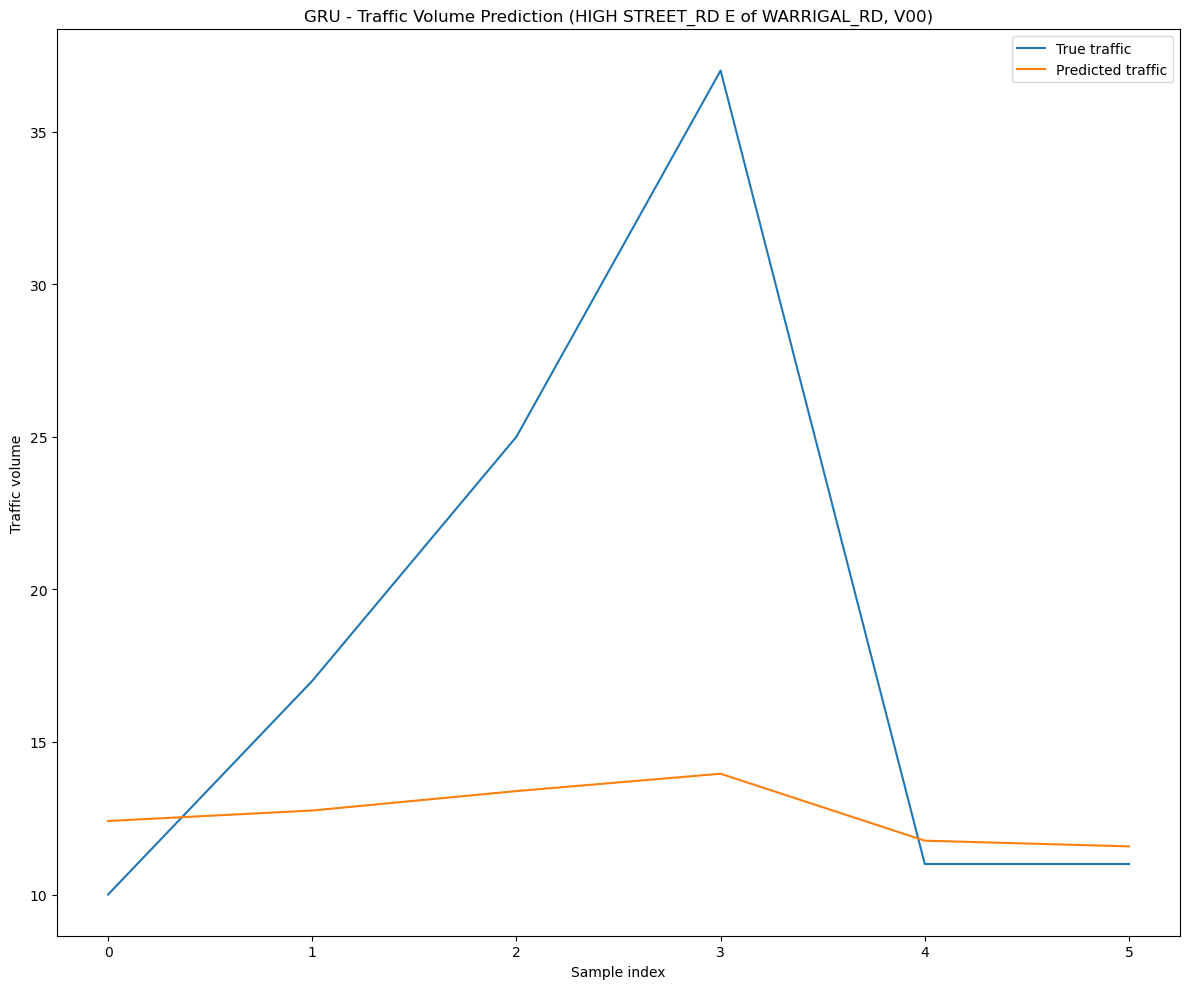

In [4]:
plt.figure(figsize=(12, 10))
plt.plot(range(len(results['y_test'])), results['y_test'].values, label='True traffic')
plt.plot(range(len(results['y_pred'])), results['y_pred'], label='Predicted traffic')
plt.title(f"GRU - Traffic Volume Prediction ({results['location']}, {results['time_column']})")
plt.xlabel('Sample index')
plt.ylabel('Traffic volume')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
plot_paths = save_gru_plots(results)
print(plot_paths)

{'prediction_plot': 'C:\\Users\\User\\OneDrive\\Documents\\GitHub\\COS30019-Assignment-2A\\Assignment-2B\\GRU\\Visualization graphs\\gru_prediction_plot.png', 'training_plot': 'C:\\Users\\User\\OneDrive\\Documents\\GitHub\\COS30019-Assignment-2A\\Assignment-2B\\GRU\\Visualization graphs\\gru_training_loss.png'}


In [6]:
prediction = traffic_gru('10/15/2006', loc_index=1, time_index=0)
print(f"Predicted traffic volume for 10/15/2006: {prediction[0]:.1f}")

Predicted traffic volume for 10/15/2006: 12.4
